# Домашнее задание №1. Pandas. numpy. Обработка данных.

## Ф.И.О: Проскуряков Иван Сергеевич

Домашнее задание состоит из **2**-х частей: 
- **Первая часть** посвящена эффективной реализации функций подсчета расстояния с использованием библиотеки _numpy_.
- **Вторая часть** предполагает заполнение предложенного блокнота.

### Часть 0.
- Вписать Ваши ФИО в предложенное поле.


### Часть 1. (5 баллов)
- реализуйте функции для вычисления расстояния из модуля ``tasks`` с использованием _numpy_
- запрещается использовать циклы и конструкцию list comprehension
- запрещается использовать сторонние библиотеки(за исключением _numpy_)
- для проверки можете использовать предложенные unit-тесты
   - чтобы запустить их в консоли выполните:
      ``$ python -m unittest``

### Часть 2. (15 баллов)
- заполните предложенный блокнот кодом и ответами на вопросы, где это требуется

----------------------------------------

**На проверку требуется отправить zip архив, который будет содержать следующие файлы:**
 - модуль ``tasks.py`` с реализованными функциями
 - заполненный блокнот в формате ``.ipybn``
 - заполненный блокнот в формате ``.html`` **(File -> Save and Export Notebook As -> HTML -> ...)**
 - файл ``answer.csv``, который получится в результате работы над блокнотом

### Часть 2. (15 points)

----------------------------

#### __1__. (2 points)

__1.1__. Импортируйте все необходимые библиотеки.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 3)

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

__1.2__. Загрузите файл `train.csv` и сохраните его в переменную `df`. Выведите первые 10 строчек таблицы.

In [2]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

df = pd.read_csv("./data/train.csv")
df.head(10)

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
0,01/10/2017,0,5200,NaN,810,21OCT17:00:00:00,5023.0,POS,0,0.0
1,01/10/2017,0,6011,NaN,810,12OCT17:12:24:07,20000.0,DEPOSIT,0,0.0
2,01/12/2017,0,5921,NaN,810,05DEC17:00:00:00,767.0,POS,0,0.0
3,01/10/2017,0,5411,NaN,810,21OCT17:00:00:00,2031.0,POS,0,0.0
4,01/10/2017,0,6012,NaN,810,24OCT17:13:14:24,36562.0,C2C_OUT,0,0.0
5,01/10/2017,1,5814,NaN,810,16OCT17:00:00:00,380.0,POS,0,0.0
6,01/10/2017,1,5814,NaN,810,10OCT17:00:00:00,378.0,POS,0,0.0
7,01/10/2017,1,5814,NaN,810,16OCT17:00:00:00,199.0,POS,0,0.0
8,01/10/2017,1,5814,NaN,810,11OCT17:00:00:00,400.0,POS,0,0.0
9,01/07/2017,1,5411,NaN,810,26JUL17:00:00:00,598.0,POS,0,0.0


In [3]:
np.random.seed(9564)
index = np.random.choice(len(df), replace=False, size=1000)

__1.3__.1. Выведите размер получившейся таблицы. 

In [4]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

table_size = df.shape[0]
print(f"Размер таблицы: {table_size}")

Размер таблицы: 490513


__1.3__.2. Выведите статистики (среднее, дисперссию, кванти́ли, количество значений и т.п.) по каждому из столбцов. Воспользуйтесь специальным методом у `df`.

In [5]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df.describe()

,cl_id,MCC,currency,amount,target_flag,target_sum
count,490513.000,490513.000,490513.000,4.905e+05,490513.000,4.905e+05
mean,4802.127,5699.784,810.602,5.724e+03,0.653,1.627e+05
std,2986.493,662.933,38.223,7.704e+04,0.476,1.474e+06
min,0.000,742.000,32.000,4.000e-02,0.000,0.000e+00
25%,2193.000,5411.000,810.000,2.240e+02,0.000,0.000e+00
50%,4576.000,5661.000,810.000,6.240e+02,1.000,2.491e+04
75%,7390.000,5941.000,810.000,2.176e+03,1.000,1.516e+05
max,10215.000,9405.000,986.000,3.584e+07,1.000,4.607e+07


Опиание столбцов:
* PERIOD – месяц транзакции;
* cl_id – id клиента;
* MCC – код категории продавца;
* channel_type – канал привлечения клиента;
* currency – валюта;
* TRDATETIME – дата/время транзакции;
* amount – сумма транзакции;
* trx_category – вид транзакции.

Виды транзакций:
* POS – оплата через POS терминал;
* C2C_IN – перевод на карту (входящий платёж);
* C2C_OUT – перевод на карту (исходящий платёж);
* DEPOSIT – пополнение карты в банкомате;
* WD_ATM_PARTNER – снятие наличных в банкоматах партнерах банка *UNKNOWN*;
* WD_ATM_ROS – снятие наличных в банкоматах банка *UNKNOWN*;
* WD_ATM_OTHER – снятия в других банкоматах;
* BACK_TRX – возврат средств при возврате покупки;
* CAT – операции в банкоматах;
* CASH_ADV – снятие карты в кассе банка.

__1.4__. Какие столбцы имеют пропущенные значения? Сколько пропущенных значений?

In [6]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
count_nan = table_size - df.count()
count_nan

PERIOD             0
cl_id              0
MCC                0
channel_type    2910
currency           0
TRDATETIME         0
amount             0
trx_category       0
target_flag        0
target_sum         0
dtype: int64

__1.5__. Какие уникальные значения существуют у столбца `currency`?

In [7]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df['currency'].unique()

array([810, 978, 504, 704, 981, 985, 840, 949,  51, 826, 214, 764, 203,
       702, 360, 756, 933, 975,  36, 191, 784, 980, 124, 398, 376, 944,
       352, 417, 156, 752, 392, 484, 634, 188, 643, 348, 356, 458, 986,
       498, 578, 208, 344,  32, 410, 788, 480, 604, 941, 144, 946, 710,
       690,  44, 170, 901, 608, 554, 462])

__1.6__. Заполните пропуски в столбце `channel_type` значением `type0`. Результат должен сохраниться в переменной `df`.

In [3]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df.fillna(value={"channel_type": "type0"}, inplace=True)

In [9]:
df.head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
0,01/10/2017,0,5200,type0,810,21OCT17:00:00:00,5023.0,POS,0,0.0
1,01/10/2017,0,6011,type0,810,12OCT17:12:24:07,20000.0,DEPOSIT,0,0.0
2,01/12/2017,0,5921,type0,810,05DEC17:00:00:00,767.0,POS,0,0.0
3,01/10/2017,0,5411,type0,810,21OCT17:00:00:00,2031.0,POS,0,0.0
4,01/10/2017,0,6012,type0,810,24OCT17:13:14:24,36562.0,C2C_OUT,0,0.0


__1.7__. Посчитайте, сколько записей приходится на каждое уникальное значение столбца `channel_type`.

In [10]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df.groupby('channel_type').count()

,PERIOD,cl_id,MCC,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
channel_type,,,,,,,,,
type0,2910,2910,2910,2910,2910,2910,2910,2910,2910
type1,299247,299247,299247,299247,299247,299247,299247,299247,299247
type2,175013,175013,175013,175013,175013,175013,175013,175013,175013
type3,3280,3280,3280,3280,3280,3280,3280,3280,3280
type4,4476,4476,4476,4476,4476,4476,4476,4476,4476
type5,5587,5587,5587,5587,5587,5587,5587,5587,5587


__1.8__. Найдите топ-3 `MCC` категорий с наибольшим объемом трат.

In [11]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

df.groupby("MCC").sum('amount').sort_values(by='amount', ascending=False).head(3)

,cl_id,currency,amount,target_flag,target_sum
MCC,,,,,
6011,250900403,44025512,1.494e+09,35524,7.760e+09
6012,52852519,8140735,1.849e+08,5709,1.099e+09
5411,606726138,98568226,1.347e+08,75343,1.395e+10


----------------------------------

#### __2__. (1 point)

__2.1__. Сделайте значения в столбцах `channel_type` и `trx_category` категориальными.

In [4]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df[['channel_type', 'trx_category']] = df[['channel_type', 'trx_category']].astype('category')

__2.2__. Сделайте столбец `trx_category_mul`, которая показывает увеличение (значение в столбце равно +1) и уменьшение средств (значение в столбце равно -1) на счете клиента банка. Операции, которые увеличивают количество средств на счете:
`C2C_IN`, `DEPOSIT`, `BACK_TRX`. Считайте, что остальные операции уменьшают количество средств на счете.

In [5]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df['trx_category_mul'] = df.apply(
    lambda x: 1 if x['trx_category'] in {'C2C_IN', 'DEPOSIT', 'BACK_TRX'} else -1, 
    axis=1
)

In [14]:
df.loc[:, ['trx_category_mul', 'trx_category']].head()

,trx_category_mul,trx_category
0,-1,POS
1,1,DEPOSIT
2,-1,POS
3,-1,POS
4,-1,C2C_OUT


-------------------------------------------------

#### __3__. (1 point)

__3.0__. Приведем столбец `TRDATETIME` к типу даты.

In [6]:
from datetime import datetime

df["TRDATETIME"] = pd.to_datetime(df["TRDATETIME"], format='%d%b%y:%H:%M:%S')

Извлеките из столбца `TRDATETIME` следующие признаки:
* `mday` – день (с начала месяца);
* `ymonth` – месяц;
* `year` – год;
* `wday` – день недели;
* `is_weekend` – является ли день выходным днем.

Извлеченные признаки запишите в таблицу `df_time`.

In [7]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

#put your code here

# https://stackoverflow.com/questions/23586510/return-multiple-columns-from-pandas-apply second anwer
data = df['TRDATETIME'].apply(
    lambda x: (x.day, x.month, x.year, x.weekday(), x.weekday() >= 5)
)
df_time = pd.DataFrame(columns=["mday", "ymonth", "year", "wday", "is_weekend"])
df_time["mday"], df_time["ymonth"], df_time["year"], df_time["wday"], df_time["is_weekend"] = zip(*data)
df_time

,mday,ymonth,year,wday,is_weekend
0,21,10,2017,5,True
1,12,10,2017,3,False
2,5,12,2017,1,False
3,21,10,2017,5,True
4,24,10,2017,1,False
...,...,...,...,...,...
490508,24,4,2017,0,False
490509,6,6,2017,1,False
490510,3,2,2017,4,False
490511,8,6,2017,3,False


In [17]:
df_time.head()

,mday,ymonth,year,wday,is_weekend
0,21,10,2017,5,True
1,12,10,2017,3,False
2,5,12,2017,1,False
3,21,10,2017,5,True
4,24,10,2017,1,False


In [18]:
df_time.shape

(490513, 5)

In [22]:
df.shape

(490513, 11)

__3.1__. Объедините таблицы `df` и `df_time` и сохраните результат в `df`. При объединении используйте аргумент `sort=False`, если он имеется.

In [8]:
pd.concat([df, df_time], axis=1)

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend
0,01/10/2017,0,5200,type0,810,2017-10-21 00:00:00,5023.00,POS,0,0.0,-1,21,10,2017,5,True
1,01/10/2017,0,6011,type0,810,2017-10-12 12:24:07,20000.00,DEPOSIT,0,0.0,1,12,10,2017,3,False
2,01/12/2017,0,5921,type0,810,2017-12-05 00:00:00,767.00,POS,0,0.0,-1,5,12,2017,1,False
3,01/10/2017,0,5411,type0,810,2017-10-21 00:00:00,2031.00,POS,0,0.0,-1,21,10,2017,5,True
4,01/10/2017,0,6012,type0,810,2017-10-24 13:14:24,36562.00,C2C_OUT,0,0.0,-1,24,10,2017,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490508,01/04/2017,10176,6011,type1,810,2017-04-24 14:05:26,600.00,WD_ATM_ROS,1,405.0,-1,24,4,2017,0,False
490509,01/06/2017,10171,5411,type1,810,2017-06-06 00:00:00,132.00,POS,0,0.0,-1,6,6,2017,1,False
490510,01/02/2017,10167,5541,type1,810,2017-02-03 00:00:00,1000.00,POS,1,280428.2,-1,3,2,2017,4,False
490511,01/06/2017,10163,5941,type1,810,2017-06-08 00:00:00,100.00,POS,0,0.0,-1,8,6,2017,3,False


In [9]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df = pd.concat([df, df_time], axis=1).reindex(df.index)

In [21]:
df.head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend
0,01/10/2017,0,5200,type0,810,2017-10-21 00:00:00,5023.0,POS,0,0.0,-1,21,10,2017,5,True
1,01/10/2017,0,6011,type0,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0,1,12,10,2017,3,False
2,01/12/2017,0,5921,type0,810,2017-12-05 00:00:00,767.0,POS,0,0.0,-1,5,12,2017,1,False
3,01/10/2017,0,5411,type0,810,2017-10-21 00:00:00,2031.0,POS,0,0.0,-1,21,10,2017,5,True
4,01/10/2017,0,6012,type0,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0,-1,24,10,2017,1,False


--------------------------

#### __4__. (1 point)

__4.1__. Загрузите таблицу `mcc_codes_ru.csv` и сохраните в переменную `df_mcc`. Выведите первые 5 строчек таблицы.

In [10]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df_mcc = pd.read_csv("./data/mcc_codes_ru.csv")
# put your code here
df_mcc.head(5)

,MCC,Название,Группа,Обновлено
0,742,Ветеринарные услуги,Контрактные услуги,31.01.18
1,763,Сельскохозяйственные кооперативы,Контрактные услуги,31.01.18
2,780,Услуги садоводства и ландшафтного дизайна,Контрактные услуги,31.01.18
3,1520,Генеральные подрядчики – жилое и коммерческое ...,Контрактные услуги,31.01.18
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",Контрактные услуги,31.01.18


__4.2__. Переименуйте столбцы в `df_mcc` следующим образом:
* `MCC` -> `MCC`;
* `Название` -> `mcc_name`;
* `Группа` -> `mcc_group`;
* `Обновлено` -> `updated`.

Результат сохраните в `df_mcc`.

In [11]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

# put your code here
df_mcc.rename(columns={"МСС": "MCC", "Название":"mcc_name", "Группа":"mcc_group", "Обновлено": "updated"}, inplace=True)

In [24]:
df_mcc.head()

,MCC,mcc_name,mcc_group,updated
0,742,Ветеринарные услуги,Контрактные услуги,31.01.18
1,763,Сельскохозяйственные кооперативы,Контрактные услуги,31.01.18
2,780,Услуги садоводства и ландшафтного дизайна,Контрактные услуги,31.01.18
3,1520,Генеральные подрядчики – жилое и коммерческое ...,Контрактные услуги,31.01.18
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",Контрактные услуги,31.01.18


__4.3__. Удалите столбец `updated` из `df_mcc`, результат сохраните в `df_mcc`.

In [12]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

# put your code here
df_mcc.drop(labels=['updated'], axis=1, inplace=True)

In [26]:
df_mcc.head()

,MCC,mcc_name,mcc_group
0,742,Ветеринарные услуги,Контрактные услуги
1,763,Сельскохозяйственные кооперативы,Контрактные услуги
2,780,Услуги садоводства и ландшафтного дизайна,Контрактные услуги
3,1520,Генеральные подрядчики – жилое и коммерческое ...,Контрактные услуги
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",Контрактные услуги


__4.4__. Закодируйте столбец `mcc_group` с помощью label-кодирования.

In [30]:
!pip install scikit-learn

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 1.1 MB/s eta 0:00:0000:0100:010m
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [13]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
from sklearn.preprocessing import LabelEncoder

groups_encoder = LabelEncoder()

groups_encoder.fit(df_mcc['mcc_group'])
df_mcc['mcc_group'] = groups_encoder.transform(df_mcc['mcc_group'])

In [33]:
df_mcc.head()

,MCC,mcc_name,mcc_group
0,742,Ветеринарные услуги,6
1,763,Сельскохозяйственные кооперативы,6
2,780,Услуги садоводства и ландшафтного дизайна,6
3,1520,Генеральные подрядчики – жилое и коммерческое ...,6
4,1711,"Генеральные подрядчики по вентиляции, теплосна...",6


--------------------------------------
#### __5__. (2 points)

__5.1__. Присоедините к таблице `df` столбец `mcc_group`. Результат сохраните в `df`.

**Какой тип JOIN-а подойдет лучше всего для этой задачи?**

$\textcolor{red}{Ваш \ ответ:}$ нужен `left outer`, т.к. `mcc_group` описывает значения из `df`, при этом мы не можем быть уверены, что все категории `mcc` из `df` есть в `mcc_group`.

In [14]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

df = df.merge(df_mcc, left_on='MCC', right_on='MCC', how='left').drop(columns=['mcc_name'])

In [35]:
df.shape

(490513, 17)

In [29]:
df[df['mcc_group'].isnull()]

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group
9259,01/05/2017,177,3824,type4,840,2017-05-15,400.09,POS,0,0.0,-1,15,5,2017,0,False,NaN
9315,01/05/2017,177,3824,type4,840,2017-05-11,424.04,POS,0,0.0,-1,11,5,2017,3,False,NaN


In [38]:
# Нашли MCC, которого нет в df_mcc
(3824 in df_mcc.MCC.unique())

False

Чтобы данные были консистентны, для mcc == 3824 сделаем группу -1

In [39]:
df[df.mcc_group == -1]

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group


In [15]:
df.fillna({"mcc_group": -1}, inplace=True)

In [31]:
df.iloc[index].head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group
51305,01/06/2017,913,7230,type2,810,2017-06-14,2100.0,POS,1,449004.29,-1,14,6,2017,2,False,7.0
226863,01/07/2017,4183,5499,type1,810,2017-07-20,140.0,POS,1,132726.55,-1,20,7,2017,3,False,17.0
124479,01/11/2017,2253,5735,type2,810,2017-11-28,397.0,POS,1,59.00,-1,28,11,2017,1,False,15.0
11132,01/08/2017,225,5411,type4,810,2017-08-07,44.9,POS,1,466235.45,-1,7,8,2017,0,False,17.0
473017,01/03/2017,9869,5812,type1,810,2017-03-30,350.0,POS,0,0.00,-1,30,3,2017,3,False,15.0


----------------------------------------

#### __6__. (2 points) 
Выведите сумму, среднее и среднеквадратичное отклонение трат `amount` по каждой из категорий `trx_category` в рамках канала привлечения `channel_type`.

In [15]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df.groupby(by=['trx_category', 'channel_type'], observed=True)['amount'].agg(['sum', 'mean', 'var'])

sum       mean        var
trx_category   channel_type                                 
BACK_TRX       type0         3.319e+04   8297.250  2.287e+07
               type1         2.055e+07  10979.486  3.045e+09
               type2         3.422e+06   4700.521  1.647e+08
               type3         3.222e+05  20139.201  1.259e+09
               type4         2.259e+05   7531.287  8.358e+08
               type5         6.224e+04   1682.229  5.435e+06
C2C_IN         type0         9.402e+05  22386.441  8.812e+08
               type1         7.037e+07  13497.176  4.603e+08
               type2         2.698e+07  14020.438  6.706e+08
               type3         8.701e+04  10876.250  1.521e+08
               type4         8.869e+05  15291.915  1.518e+08
               type5         6.334e+05  10556.333  1.387e+08
C2C_OUT        type0         2.033e+05   4148.317  4.151e+07
               type1         4.609e+07  16562.824  6.634e+08
               type2         3.938e+07  15804.485  6.587e+08
               type3         3.543e+04   5061.857  5.729e+07
               type4         1.846e+06  20977.273  6.795e+08
               type5         5.111e+05  13812.508  4.233e+08
CASH_ADV       type1         6.548e+05  25185.410  3.513e+09
               type2         2.580e+05  32250.535  2.725e+09
CAT            type0         8.404e+04   9338.331  4.694e+07
               type1         7.320e+06  16087.923  5.496e+09
               type2         1.045e+07  16335.570  6.654e+09
               type3         2.408e+06  63373.589  1.504e+10
               type4         6.288e+04  12575.312  3.009e+08
               type5         2.273e+06  45459.432  9.459e+08
DEPOSIT        type0         2.608e+06  18363.380  3.813e+08
               type1         3.691e+08  21132.086  7.487e+08
               type2         8.448e+07  30597.081  1.519e+09
               type3         4.344e+06  23227.273  5.338e+08
               type4         1.190e+07  39282.607  1.772e+09
               type5         1.036e+07  28865.955  1.133e+09
POS            type0         4.414e+06   1776.817  3.861e+07
               type1         6.323e+08   2472.164  4.932e+09
               type2         3.464e+08   2357.908  9.660e+09
               type3         7.837e+06   2755.509  1.126e+08
               type4         1.169e+07   3138.924  5.396e+08
               type5         1.036e+07   2218.382  4.227e+08
WD_ATM_OTHER   type0         1.112e+06  52933.333  5.064e+10
               type1         3.840e+07  19145.017  3.160e+10
               type2         3.421e+07   6909.320  1.053e+09
               type3         2.460e+05   9840.080  3.962e+08
               type4         1.829e+05   4572.299  1.926e+07
               type5         6.203e+05   6461.146  2.750e+08
WD_ATM_PARTNER type0         2.285e+05   6528.571  2.743e+08
               type1         2.264e+08  47388.371  5.087e+09
               type2         9.920e+07  20572.605  1.147e+09
               type3         2.386e+06  28401.190  1.306e+09
               type4         3.161e+06  38085.542  3.208e+09
               type5         1.367e+06   9300.000  3.679e+08
WD_ATM_ROS     type0         1.796e+06  14487.097  1.003e+09
               type1         3.837e+08  43278.339  3.106e+09
               type2         2.699e+08  27632.246  1.893e+09
               type3         2.274e+06  32023.944  2.023e+09
               type4         7.700e+06  53475.694  4.411e+09
               type5         2.724e+06  20636.364  1.035e+09

---------------------------------

#### __7__. (2 points) 

Выведите топ-5 клиентов, с наибольшим оборотом по `С2С` транзакциям. Под оборотом подразумевается полный объем полученных и переведенных средств без учета знака (т.е. не имеет значения получал ли клиент средства на свой счет, или переводил их на другой счет).

In [16]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
df[['cl_id', 'amount', 'trx_category']][(df.trx_category == 'C2C_OUT') | (df.trx_category == 'C2C_IN')].groupby(by="cl_id").sum("amount").sort_values(by='amount',ascending=False).head(5).index.values

array([4445, 1408, 4211, 5373, 4340])

-------------------------------------------

#### __8__. (2 points) 

__8.1.__ Прологарифмируйте сумму трат `amount`, а результат сохраните в столбец `amount_log`. Как нужно логарифмировать, чтобы не было проблем при `amount == 0`?

In [16]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
# Т.к. мы не можем сравнивать точно, и речь идёт о деньгах, возьмём eps и будем сравнивать с ним
eps = np.float64(0.009)

df['amount_log'] =  df['amount'].apply(
    lambda x: None if x - eps < 0 else np.log(x)
)
df.amount_log

0          8.522
1          9.903
2          6.642
3          7.616
4         10.507
           ...  
490508     6.397
490509     4.883
490510     6.908
490511     4.605
490512     6.090
Name: amount_log, Length: 490513, dtype: float64

In [46]:
df

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group,amount_log
0,01/10/2017,0,5200,type0,810,2017-10-21 00:00:00,5023.00,POS,0,0.0,-1,21,10,2017,5,True,17.0,8.522
1,01/10/2017,0,6011,type0,810,2017-10-12 12:24:07,20000.00,DEPOSIT,0,0.0,1,12,10,2017,3,False,11.0,9.903
2,01/12/2017,0,5921,type0,810,2017-12-05 00:00:00,767.00,POS,0,0.0,-1,5,12,2017,1,False,15.0,6.642
3,01/10/2017,0,5411,type0,810,2017-10-21 00:00:00,2031.00,POS,0,0.0,-1,21,10,2017,5,True,17.0,7.616
4,01/10/2017,0,6012,type0,810,2017-10-24 13:14:24,36562.00,C2C_OUT,0,0.0,-1,24,10,2017,1,False,11.0,10.507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490508,01/04/2017,10176,6011,type1,810,2017-04-24 14:05:26,600.00,WD_ATM_ROS,1,405.0,-1,24,4,2017,0,False,11.0,6.397
490509,01/06/2017,10171,5411,type1,810,2017-06-06 00:00:00,132.00,POS,0,0.0,-1,6,6,2017,1,False,17.0,4.883
490510,01/02/2017,10167,5541,type1,810,2017-02-03 00:00:00,1000.00,POS,1,280428.2,-1,3,2,2017,4,False,1.0,6.908
490511,01/06/2017,10163,5941,type1,810,2017-06-08 00:00:00,100.00,POS,0,0.0,-1,8,6,2017,3,False,15.0,4.605


__8.2__. Выполните onehot-кодирование для столбцов `channel_type` и `trx_category`. Полученные столбцы присоедините к таблице `df`, результат сохраните в переменную `df`.  

In [35]:
df[['channel_type', 'trx_category']][df['channel_type'].isna()]

,channel_type,trx_category


In [17]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################

# put your code here
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = OneHotEncoder()

encoded = one_hot_enc.fit_transform(df[['channel_type', 'trx_category']]).toarray()
df = pd.concat([df, pd.DataFrame(encoded, columns=one_hot_enc.get_feature_names_out())], axis=1)

In [37]:
df.iloc[index].head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,trx_category_mul,mday,ymonth,year,wday,is_weekend,mcc_group,amount_log,channel_type_type0,channel_type_type1,channel_type_type2,channel_type_type3,channel_type_type4,channel_type_type5,trx_category_BACK_TRX,trx_category_C2C_IN,trx_category_C2C_OUT,trx_category_CASH_ADV,trx_category_CAT,trx_category_DEPOSIT,trx_category_POS,trx_category_WD_ATM_OTHER,trx_category_WD_ATM_PARTNER,trx_category_WD_ATM_ROS
51305,01/06/2017,913,7230,type2,810,2017-06-14,2100.0,POS,1,449004.29,-1,14,6,2017,2,False,7.0,7.650,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
226863,01/07/2017,4183,5499,type1,810,2017-07-20,140.0,POS,1,132726.55,-1,20,7,2017,3,False,17.0,4.942,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
124479,01/11/2017,2253,5735,type2,810,2017-11-28,397.0,POS,1,59.00,-1,28,11,2017,1,False,15.0,5.984,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
11132,01/08/2017,225,5411,type4,810,2017-08-07,44.9,POS,1,466235.45,-1,7,8,2017,0,False,17.0,3.804,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
473017,01/03/2017,9869,5812,type1,810,2017-03-30,350.0,POS,0,0.00,-1,30,3,2017,3,False,15.0,5.858,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


-----------------------------------------

#### __9__. (2 points за правильную итоговую подтаблицу)

Сохраните итоговую подтаблицу в файл.

In [52]:
df.iloc[index].to_csv('answer.csv', index=False, sep=',')

-----------------------------------------

## Бонусная часть (+3 балла)

Попробуйте придумать решающее правило (без использования алгоритмов машинного обучения), по которому можно было бы предсказать значение переменной `target_flag`. **Запрещается** использовать переменную `target_sum`.

Разобъем выборку на тренировочную и отложенную.

In [18]:
from sklearn.model_selection import train_test_split

mask = df.columns.str.startswith('target_')

target_cols  = df.columns[mask]
feature_cols = df.columns[~mask]

X, y = df.loc[:, feature_cols], df.loc[:, target_cols]

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, shuffle=True, random_state=9872)

Ваше решение должно побить следующий бейзлайн:

```python
from sklearn.metrics import accuracy_score

assert accuracy_score(y_test['target_flag'], y_pred) > 0.7
```

**Запрещается** использовать отложенную выборку `(X_test, y_test)` для выбора решения.

**Вопрос:** Что показывает метрика `accuracy`?

$\textcolor{red}{Ваш \ ответ:}$ `accuracy` показывает долю правильных ответов в предсказании по тестовой выборке

### Вопросы и подсказки

Исследуйте рапределения и зависимости между признаками отностительно целевой переменной `target_flag`. Для решения этой задачи вам может быть полезна визуализация.

1. Какие любопытные выводы можно сделать из такого анализа?
2. Какие проблемы возникают с визуализацией совместного распредления категориальных (дискретных) и непрерывных значений? Как эту проблему можно решить?
3. В исходном датасете очень много записей, поэтому визуализация может работать **неприемлемо** долго. Как решить эту проблему?

Приведите ниже код и комментарии с ответами на вопросы выше.

__Ответы на вопросы:__

**1.**:
    
    - `target_flag` сильно зависит от канала привлечения

    - Порядок трат в каждой категории `target_flag` расположен достаточно ассиметрично, но с некоторой натяжкой можно натянуть на нормальное распределение

**2.**  _put your answers here_

**3.** Можно выводить не весь датасет, а часть. Правда, которую, вопрос сложный, с которым я не справился.

<Axes: xlabel='channel_type', ylabel='Count'>

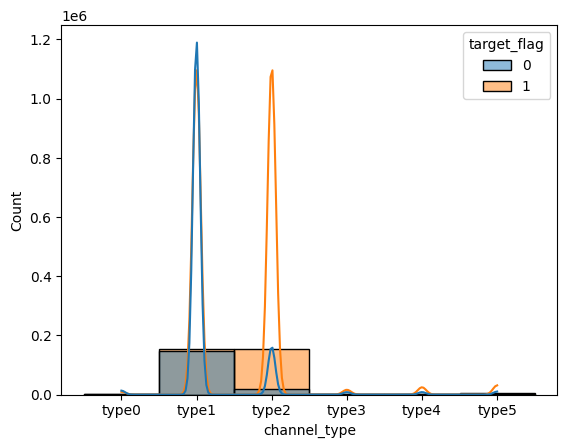

In [19]:
import seaborn as sns

sns.histplot(df, x='channel_type', kde=True, hue='target_flag')

<Axes: xlabel='channel_type', ylabel='Count'>

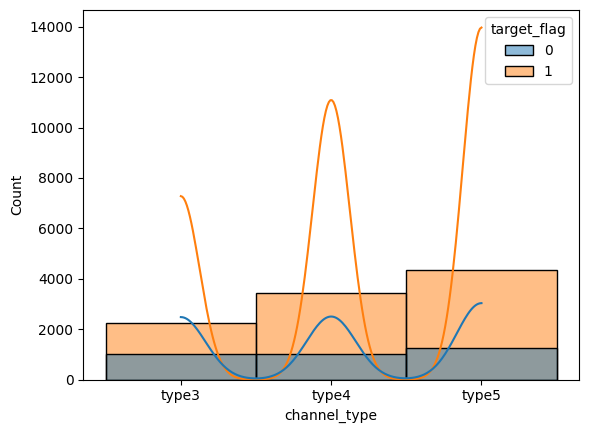

In [37]:
sns.histplot(df[(df['channel_type'] == 'type3') | (df['channel_type'] == 'type4') | (df['channel_type'] == 'type5')], x='channel_type', kde=True, hue='target_flag')


<Axes: xlabel='amount_log', ylabel='Count'>

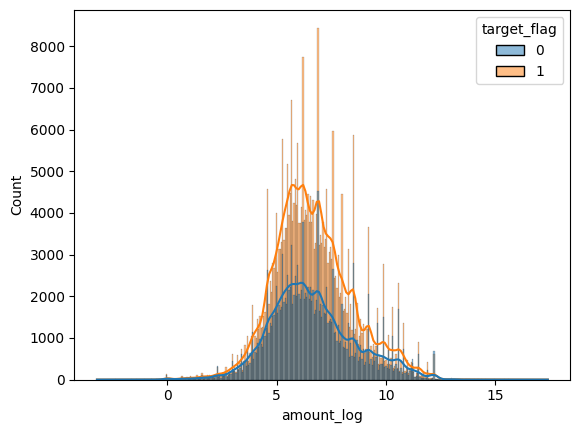

In [45]:
sns.histplot(df, x='amount_log', kde=True, hue='target_flag')


### Решение

In [ ]:
type3_prob_1 = (df[(df['channel_type'] == 'type3') & (df['target_flag'] == 1)].count() / df[(df['channel_type'] == 'type3')].count()).values[0]
type4_prob_1 = (df[(df['channel_type'] == 'type4') & (df['target_flag'] == 1)].count() / df[(df['channel_type'] == 'type4')].count()).values[0]
type5_prob_1 = (df[(df['channel_type'] == 'type5') & (df['target_flag'] == 1)].count() / df[(df['channel_type'] == 'type5')].count()).values[0]

In [48]:
random_generator = np.random.default_rng(88005553535)

In [74]:
df.groupby(by=['target_flag'], observed=True)['amount_log'].agg(['mean', 'var'])

,mean,var
target_flag,,
0,6.628,3.771
1,6.654,3.234


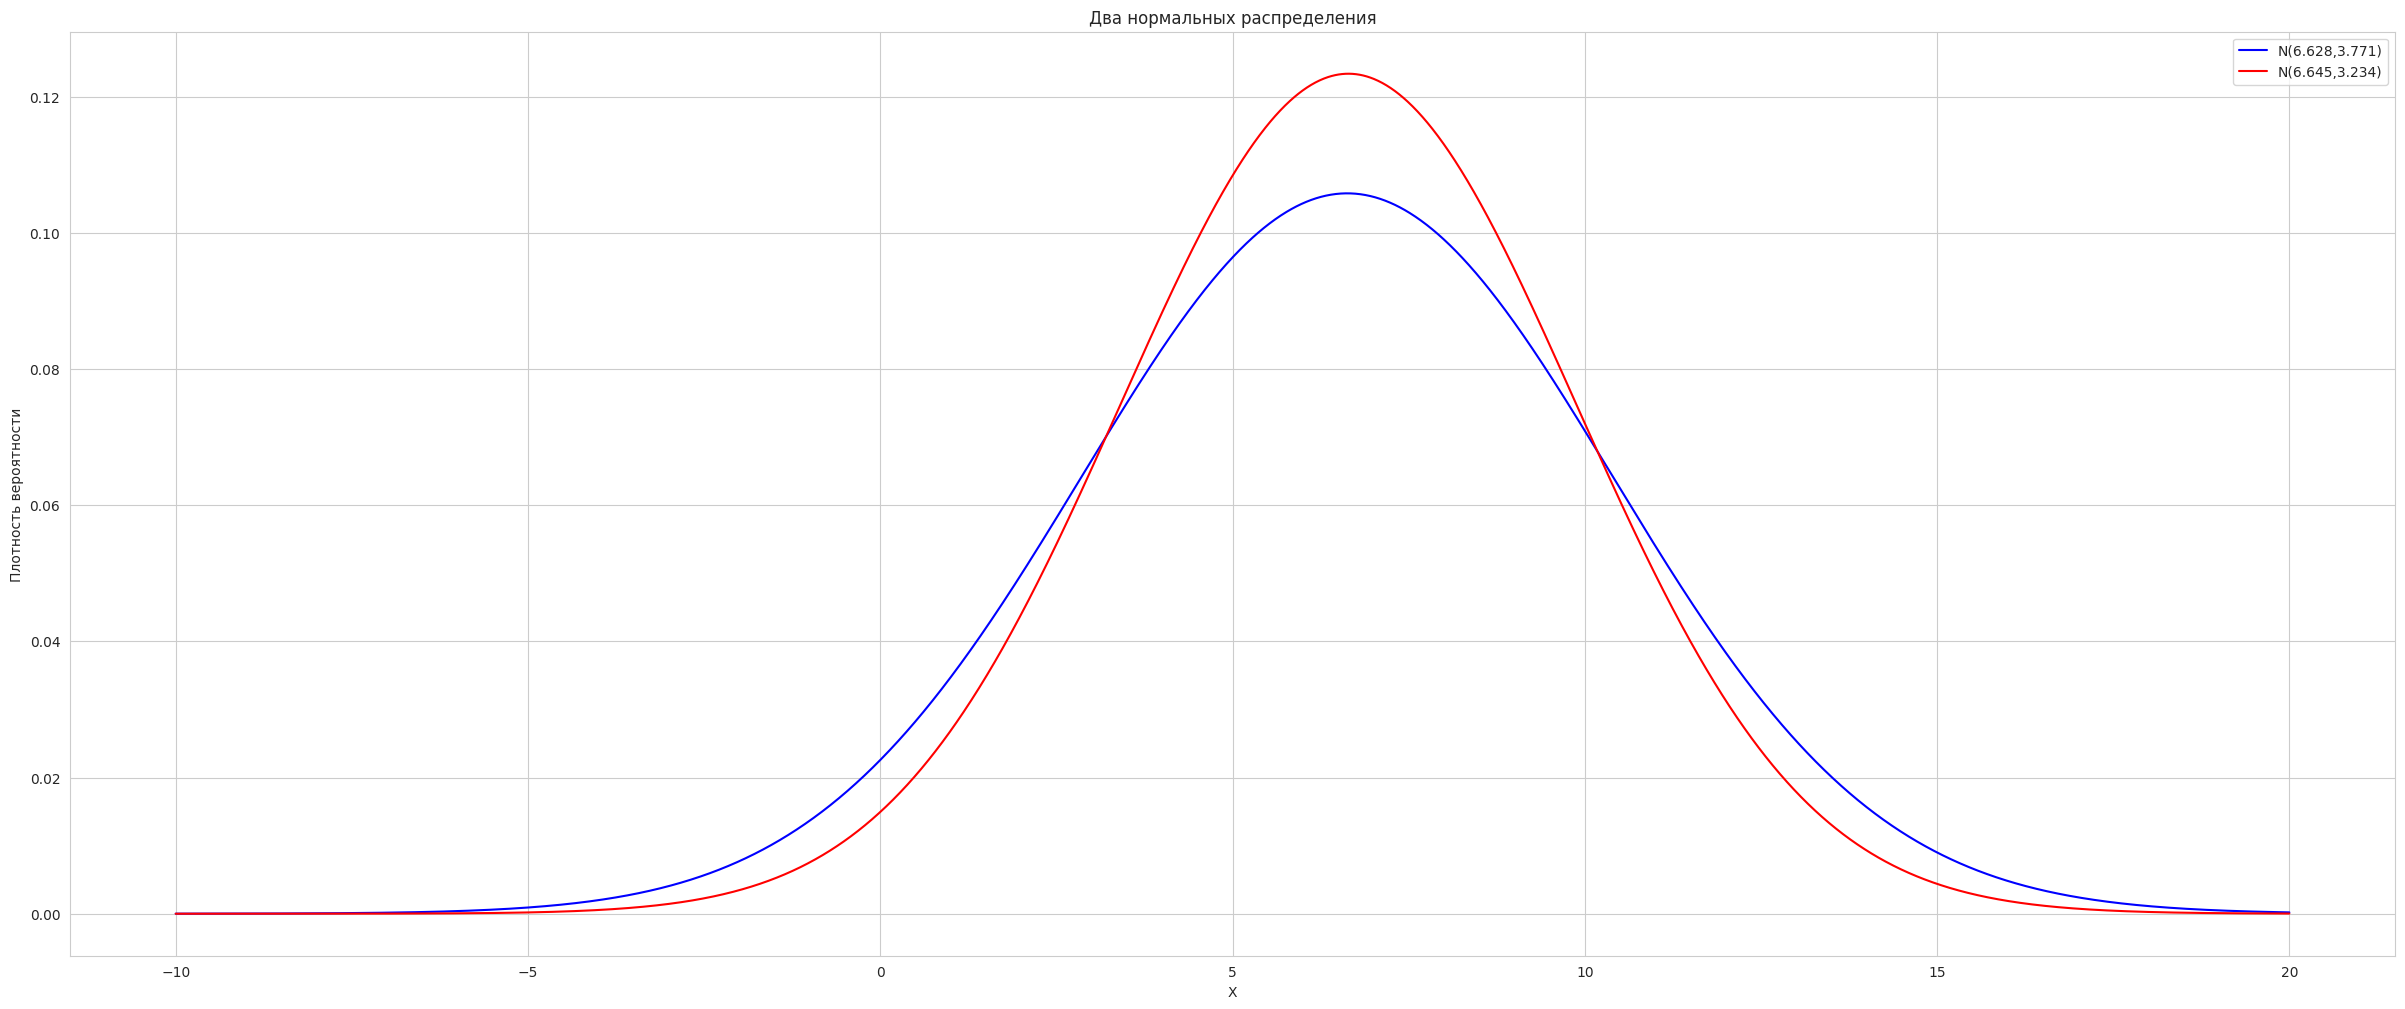

In [79]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Устанавливаем стиль для красивого отображения
sns.set_style("whitegrid")

# Задаем параметры распределений
a_1 = 6.628    # Среднее для первого распределения
b_1 = 3.771    # Стандартное отклонение для первого распределения
a_2 = 6.645    # Среднее для второго распределения
b_2 = 3.234    # Стандартное отклонение для второго распределения

# Создаем данные для двух нормальных распределений
x = np.linspace(-10, 20, 3000)  # Создаем массив точек по оси X

# Первое нормальное распределение
dist1 = (1/(np.sqrt(2 * np.pi * b_1**2))) * np.exp(-(x - a_1)**2 / (2 * b_1**2))

# Второе нормальное распределение
dist2 = (1/(np.sqrt(2 * np.pi * b_2**2))) * np.exp(-(x - a_2)**2 / (2 * b_2**2))

# Создаем графики с помощью seaborn
plt.figure(figsize=(30, 12))  # Задаем размер картинки
sns.lineplot(x=x, y=dist1, label=f'N({a_1},{b_1})', color='blue')  # Первый график
sns.lineplot(x=x, y=dist2, label=f'N({a_2},{b_2})', color='red')   # Второй график

# Настраиваем график
plt.title('Два нормальных распределения')
plt.xlabel('X')
plt.ylabel('Плотность вероятности')
plt.legend()  # Добавляем легенду

# Показываем график
plt.show()

При таком построении распределения очень похожи. Возможно, это результат учёта выбросов, которые видны на histplot для `amount_log` выше. Чистить от них выборку уже, кажется, выходит за рамки пройденного материала, поэтому заниматься этим не буду. Кроме того, чтобы расставлять метки по нормальному закону, придётся либо вручную писать фунцию плотности, либо импортировать `scipy`: второе запрещено по ТЗ, первое делать откровенно в лом, поэтому дальше попробуем обойтись только одним фактором

In [ ]:
# put your code here
# кажется, тут ещё надо использовать данные распределения `amount_log`
def solver(type, generator, prob3, prob4, prob5):
    if type == 'type1':
        return 0
    elif type == 'type2':
        return 1
    elif type == 'type3':
        answer = generator.uniform(size=1)
        if answer > prob3:
            return 0
        else:
            return 1
    elif type == 'type4':
        answer = generator.uniform(size=1)
        if answer > prob4:
            return 0
        else:
            return 1
    elif type == 'type5':
        answer = generator.uniform(size=1)
        if answer > prob5:
            return 0
        else:
            return 1
    else:
        return 0

In [72]:
#############################
### ╰( ͡° ͜ʖ ͡° )つ──────☆*:・ﾟ
#############################
y_pred = X_test.apply(
    lambda row: solver(row['channel_type'], random_generator, type3_prob_1, type4_prob_1, type5_prob_1),
    axis=1
)

In [73]:
# я не справилься :(
from sklearn.metrics import accuracy_score
accuracy_score(y_test['target_flag'], y_pred)

0.6353004335594004

Фокус не удался:(